In [1]:
!pip install python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 4.3 MB/s eta 0:00:00


In [10]:
from docx import Document
from docx.shared import RGBColor
import csv
import random
from pathlib import Path
import spacy
from spacy.tokens import DocBin
from pathlib import Path
import re
import json
from spacy.tokens import Span
from spacy.language import Language

In [3]:
INPUT = "/content/drive/MyDrive/Диплом 2/код/labeling/Complete/Manually labeled data.json"
TRAIN_OUT = "/content/drive/MyDrive/Диплом 2/код/training/Train data.spacy"
TEST_OUT  = "/content/drive/MyDrive/Диплом 2/код/training/Test data.spacy"

In [5]:
REDACTED_INPUT = "/content/drive/MyDrive/Диплом 2/код/labeling/Complete/Manually labeled data_no_time_date.json"

with open(INPUT, "r", encoding="utf-8") as f:
    data = json.load(f)
for item in data:
    if "entities" in item:
        item["entities"] = [
            ent for ent in item["entities"]
            if ent["label"] not in ["TIME", "DATE"]
        ]
with open(REDACTED_INPUT, "w", encoding="utf-8") as f:
    json.dump(data, f, ensure_ascii=False, indent=2)

print(f"Новий файл збережено: {REDACTED_INPUT}")
INPUT=REDACTED_INPUT

Новий файл збережено: /content/drive/MyDrive/Диплом 2/код/labeling/Complete/Manually labeled data_no_time_date.json


In [6]:
#Перетворення CSV в .spacy
SPLIT = 0.8
nlp = spacy.blank("en")

def filter_overlaps(spans):
    spans = sorted(spans, key=lambda x: (x.start, -(x.end - x.start)))
    result = []
    occupied = set()
    for span in spans:
        token_range = set(range(span.start, span.end))
        if occupied.intersection(token_range):
            continue
        result.append(span)
        occupied.update(token_range)
    return result

def convert(data, output):
    db = DocBin()
    for item in data:
        text = item["data"]["text"]
        doc = nlp.make_doc(text)
        spans = []
        for ann in item["annotations"]:
            for r in ann["result"]:
                if r["type"] != "labels":
                    continue
                start = r["value"]["start"]
                end = r["value"]["end"]
                label = r["value"]["labels"][0]
                span = doc.char_span(start, end, label=label, alignment_mode="contract")
                if span:
                    spans.append(span)
        spans = filter_overlaps(spans)
        doc.ents = spans
        db.add(doc)
    db.to_disk(output)

data = json.load(open(INPUT, encoding="utf8"))
random.shuffle(data)
split = int(len(data) * SPLIT)
train = data[:split]
test = data[split:]
convert(train, TRAIN_OUT)
convert(test, TEST_OUT)

In [7]:
!pip install -U spacy
!python -m spacy download en_core_web_sm
!python -m spacy init config config.cfg --lang en --pipeline ner --optimize efficiency --force

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 83.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
⚠ To generate a more effective transformer-based config (GPU-only),
install the spacy-transformers package and re-run this command. The config
generated now does not use transformers.
ℹ Generated config template specific for your use case
- Language: en
- Pipeline: ner
- Optimize for: efficiency
- Hardware: CPU
- Transformer: None
✔ Auto-filled config with all values
✔ Saved config
config.cfg
You can now add your data and train your pipeline:
python -m spacy train config.cfg --paths.train ./train.spacy --paths.dev ./dev.spacy


In [8]:

cfg = Path("config.cfg").read_text()

cfg = cfg.replace("train = null", f"train = {TRAIN_OUT}")
cfg = cfg.replace("dev = null", f"dev = {TEST_OUT}")
Path("config.cfg").write_text(cfg)

2806

In [9]:
!python -m spacy train config.cfg --output './drive/MyDrive/Диплом 2/код/model' --training.max_steps 10000

ℹ Saving to output directory: drive/MyDrive/Диплом 2/код/model
ℹ Using CPU

=========================== Initializing pipeline ===========================
✔ Initialized pipeline

============================= Training pipeline =============================
ℹ Pipeline: ['tok2vec', 'ner']
ℹ Initial learn rate: 0.001
E    #       LOSS TOK2VEC  LOSS NER  ENTS_F  ENTS_P  ENTS_R  SCORE 
---  ------  ------------  --------  ------  ------  ------  ------
  0       0          0.00     40.87    0.00    0.00    0.00    0.00
  1     200       1458.13   4083.38   57.54   62.08   53.62    0.58
  3     400       3804.21   2142.09   70.32   74.04   66.96    0.70
  5     600        259.37   1181.12   75.30   79.42   71.59    0.75
  8     800        623.18   1145.63   75.34   79.87   71.30    0.75
 10    1000        425.50    849.85   71.89   73.41   70.43    0.72
 14    1200        393.34    653.68   73.77   78.88   69.28    0.74
 18    1400        439.93    506.07   73.08   74.62   71.59    0.73
 23  

In [15]:
DATE_PATTERN = re.compile(
    r"\b("
    r"(June|July|August)\s+1944"
    r"|"
    r"\d{1,2}-\d{1,2}\s+(June|July|August)"
    r"|"
    r"\d{1,2}\s+(June|July|August)"
    r")\b",
    re.IGNORECASE
)

DDAY_PATTERN = re.compile(
    r"\b(D[-\s]?Day|D\s+(plus|minus)\s+\d+)\b",
    re.IGNORECASE
)

TIME_PATTERN = re.compile(r"\b\d{4}B?\b")

RELATIVE_TIME_PATTERN = re.compile(
    r"\b\d+\s+(minutes?|hours?)\s+later\b",
    re.IGNORECASE
)

@Language.component("date_time_regex")
def date_time_regex_component(doc):

    new_ents = list(doc.ents)

    def overlaps(start, end, ents):
        for ent in ents:
            if start < ent.end_char and end > ent.start_char:
                return True
        return False

    # DATE
    for match in DATE_PATTERN.finditer(doc.text):
        start, end = match.start(), match.end()
        if not overlaps(start, end, new_ents):
            span = doc.char_span(start, end, label="DATE")
            if span:
                new_ents.append(span)

    # D-Day
    for match in DDAY_PATTERN.finditer(doc.text):
        start, end = match.start(), match.end()
        if not overlaps(start, end, new_ents):
            span = doc.char_span(start, end, label="D_DAY_REF")
            if span:
                new_ents.append(span)

    # TIME
    for match in TIME_PATTERN.finditer(doc.text):
        start, end = match.start(), match.end()
        if not overlaps(start, end, new_ents):
            span = doc.char_span(start, end, label="TIME")
            if span:
                new_ents.append(span)

    # RELATIVE TIME
    for match in RELATIVE_TIME_PATTERN.finditer(doc.text):
        start, end = match.start(), match.end()
        if not overlaps(start, end, new_ents):
            span = doc.char_span(start, end, label="REL_TIME")
            if span:
                new_ents.append(span)

    doc.ents = new_ents

    return doc
FORBIDDEN_LABELS = {"TIME", "DATE", "REL_TIME", "D_DAY_REF"}

@Language.component("remove_model_time_entities")
def remove_model_time_entities(doc):

    filtered = [ent for ent in doc.ents if ent.label_ not in FORBIDDEN_LABELS]

    doc.ents = filtered
    return doc

In [16]:
nlp = spacy.load('/content/drive/MyDrive/Диплом 2/код/model/model-last')
nlp.add_pipe("remove_model_time_entities", after="ner")
nlp.add_pipe("date_time_regex", after="remove_model_time_entities")

file_path = "/content/drive/MyDrive/Диплом 2/код/AAR_texts_clean/1st US Infantry Division  After Action Reports  June 1944/"
file_name = "035_G3  Operations  June 1944  After Action Report"
with open(file_path+file_name+".txt", "r", encoding="utf-8") as f:
    text = f.read()
print(text)

Battle of Normandy
»
After Action Reports
»
1st Infantry Division – Battle of Normandy – After Action Reports
1st Infantry Division – G3 operations – After Action Report
1st (US) Infantry Division – June 1944
G3 – Operations
After Action Report
Headquarters 1st US Inf. Div.
APO #1, U. S. Army
G-3-Ops.
1st. Inf. Div.
A. 6 June 1944
First wave was landed at 0635B 6 June and the second wave at 0636B. The 16th Infantry and 116th Infantry were landed at 0635B. Word was received by the USS CHASE at 0655B that the entire first wave had floundered. The advance Division command post with the Assistant Division Commander landed on Beach Easy Red at 0839B and opened a temporary command post above the high water line below the top of a shelf of coarse gravel extending along that part of the beach and some casualties were suffered by the command post group and the Military Police Platoon. The remainder of the advance Division command post established a temporary command post aboard the control craf

In [18]:
docx_path = "/content/drive/MyDrive/Диплом 2/код/labeled/"
docx_end = " colored4.docx"
csv_end = " entities4.csv"

docx_file = docx_path + file_name + docx_end
csv_file = docx_path + file_name + csv_end

doc = Document()

colors = {
    "PER": "00FFFF",
    "ORG": "FFA500",
    "LOC": "0000FF",
    "TIME": "FF00FF",
    "DATE": "DDA0DD",
    "REL_TIME": "8A2BE2",
    "D_DAY_REF": "FF1493",
    "MISC": "808080",
    "LOSSES": "FF6347",
    "ASSETS": "7CFC00",
    "GAINS": "556B2F",
}

# ===================== DOCX =====================

# Легенда
legend_paragraph = doc.add_paragraph()
legend_paragraph.add_run("Legend: ")
for i, (label, hex_color) in enumerate(colors.items()):
    run = legend_paragraph.add_run(label)
    run.font.color.rgb = RGBColor.from_string(hex_color)
    if i < len(colors) - 1:
        legend_paragraph.add_run(", ")
legend_paragraph.add_run("\n\n")

# Текст з підсвіткою
p = doc.add_paragraph()
cursor = 0

doc_spacy = nlp(text)

for ent in doc_spacy.ents:
    if cursor < ent.start_char:
        p.add_run(text[cursor:ent.start_char])

    run = p.add_run(ent.text)
    hex_color = colors.get(ent.label_, "000000")
    run.font.color.rgb = RGBColor.from_string(hex_color)

    cursor = ent.end_char

if cursor < len(text):
    p.add_run(text[cursor:])

doc.save(docx_file)

# ===================== CSV =====================

with open(csv_file, mode="w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)

    # Заголовок
    writer.writerow(["full_text", "entity_text", "label", "start_char", "end_char"])

    # 🔹 Перший рядок — тільки повний текст
    writer.writerow([text, "", "", "", ""])

    # 🔹 Далі — тільки сутності (без дублювання тексту)
    for ent in doc_spacy.ents:
        writer.writerow([
            "",  # full_text пустий
            ent.text,
            ent.label_,
            ent.start_char,
            ent.end_char
        ])

print(f"DOCX збережено у {docx_file}")
print(f"CSV збережено у {csv_file}")

DOCX збережено у /content/drive/MyDrive/Диплом 2/код/labeled/035_G3  Operations  June 1944  After Action Report colored4.docx
CSV збережено у /content/drive/MyDrive/Диплом 2/код/labeled/035_G3  Operations  June 1944  After Action Report entities4.csv


In [ ]:
from collections import defaultdict
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from spacy.tokens import DocBin
import pandas as pd

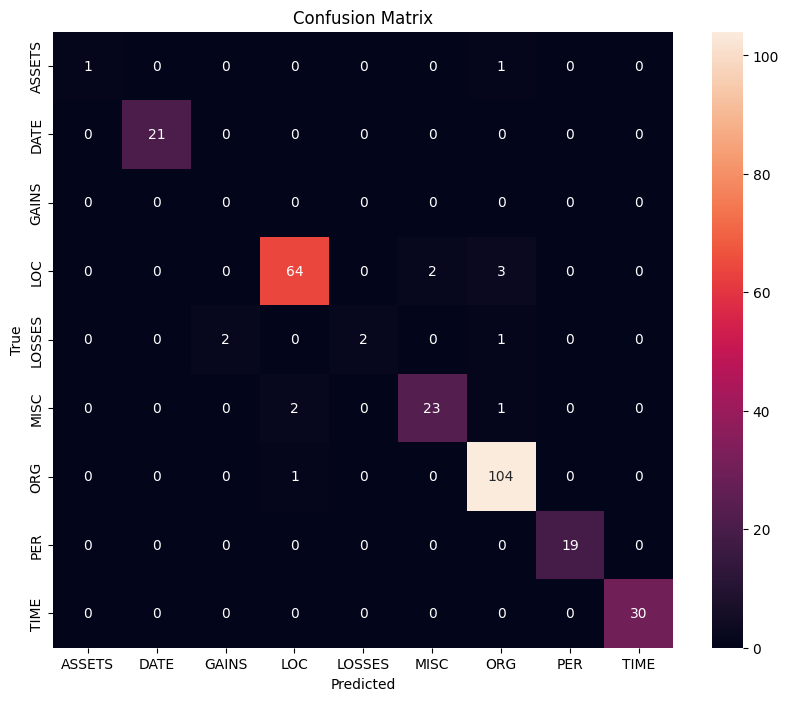


Classification Report:

              precision    recall  f1-score   support

      ASSETS       1.00      0.50      0.67         2
        DATE       1.00      1.00      1.00        21
       GAINS       0.00      0.00      0.00         0
         LOC       0.96      0.93      0.94        69
      LOSSES       1.00      0.40      0.57         5
        MISC       0.92      0.88      0.90        26
         ORG       0.95      0.99      0.97       105
         PER       1.00      1.00      1.00        19
        TIME       1.00      1.00      1.00        30

    accuracy                           0.95       277
   macro avg       0.87      0.74      0.78       277
weighted avg       0.96      0.95      0.95       277


FALSE POSITIVES:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,text,entity,label
0,General Barton decided to exploit these succes...,the 3d moved,ORG
1,General Barton decided to exploit these succes...,Tourlaville unopposed,LOC
2,General Barton decided to exploit these succes...,"eight hundred prisoners during the day, in its...",LOSSES
3,The 22d Infantry reached the ridge but was una...,22d Infantry,ORG
4,The 22d Infantry reached the ridge but was una...,The 2d Battalion made,ORG
5,All Pathfinder personnel at Division CP assist...,Pathfinder personnel,PER
6,All Pathfinder personnel at Division CP assist...,June 6/44,DATE
7,All Pathfinder personnel at Division CP assist...,2054,TIME
8,All Pathfinder personnel at Division CP assist...,2030 and Smoke,ORG
9,Early on 12 June the 39th Infantry fanned out ...,Fontenay-sur-Mer,LOC



FALSE NEGATIVES:


,text,entity,label
0,General Barton decided to exploit these succes...,3d,ORG
1,General Barton decided to exploit these succes...,Tourlaville,LOC
2,General Barton decided to exploit these succes...,eight hundred prisoners,GAINS
3,The 22d Infantry reached the ridge but was una...,The 22d Infantry,ORG
4,The 22d Infantry reached the ridge but was una...,The 2d Battalion,ORG
5,The 22d Infantry reached the ridge but was una...,les Fieffes-Dancel,LOC
6,The 22d Infantry reached the ridge but was una...,number of casualties,LOSSES
7,The battalions had hardly reached their new po...,four days and nights,DATE
8,The battalions had hardly reached their new po...,heavy casualties,LOSSES
9,The battalions had hardly reached their new po...,two light tanks,LOSSES


In [ ]:
doc_bin = DocBin().from_disk(TEST_OUT)
true_docs = list(doc_bin.get_docs(nlp.vocab))

# ===============================
# 3️⃣ Отримуємо predictions
# ===============================
pred_docs = [nlp(doc.text) for doc in true_docs]

# ===============================
# 4️⃣ Готуємо списки для метрик
# ===============================
true_labels = []
pred_labels = []

false_positives = []
false_negatives = []

for true_doc, pred_doc in zip(true_docs, pred_docs):

    true_ents = {(ent.start_char, ent.end_char): ent.label_ for ent in true_doc.ents}
    pred_ents = {(ent.start_char, ent.end_char): ent.label_ for ent in pred_doc.ents}

    # True positives + false negatives
    for span, label in true_ents.items():
        if span in pred_ents:
            true_labels.append(label)
            pred_labels.append(pred_ents[span])
        else:
            false_negatives.append({
                "text": true_doc.text,
                "entity": true_doc.text[span[0]:span[1]],
                "label": label
            })

    # False positives
    for span, label in pred_ents.items():
        if span not in true_ents:
            false_positives.append({
                "text": pred_doc.text,
                "entity": pred_doc.text[span[0]:span[1]],
                "label": label
            })

# ===============================
# 5️⃣ Confusion Matrix
# ===============================
labels = sorted(list(set(true_labels + pred_labels)))

cm = confusion_matrix(true_labels, pred_labels, labels=labels)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# ===============================
# 6️⃣ Classification Report
# ===============================
print("\nClassification Report:\n")
print(classification_report(true_labels, pred_labels))

# ===============================
# 7️⃣ False Positives / Negatives
# ===============================
fp_df = pd.DataFrame(false_positives)
fn_df = pd.DataFrame(false_negatives)

print("\nFALSE POSITIVES:")
display(fp_df.head(20))

print("\nFALSE NEGATIVES:")
display(fn_df.head(20))